In [1]:
import numpy as np
import matplotlib.pyplot as plt

import gzip

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset

from torchmetrics import Accuracy
from tqdm import tqdm

# Functions & Utils

In [2]:
seed = 0

batch_size = 128

device = device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
def set_seed(seed):
  np.random.seed(seed)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
      torch.cuda.manual_seed(seed)

In [4]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [5]:
def train_one_epoch(model, train_loader, loss_fn, optimizer, epoch=None):
    model.train()
    loss_train = AverageMeter()
    acc_train = Accuracy(task="multiclass", num_classes=2).to(device)
    with tqdm(train_loader, unit="batch") as tepoch:
        for inputs, targets in tepoch:
            if epoch is not None:
                tepoch.set_description(f"Epoch {epoch}")
                
            optimizer.zero_grad()

            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
      
            loss = loss_fn(outputs, targets)

            loss.backward()
            optimizer.step()

            loss_train.update(loss.item())
            acc_train(outputs, targets.int())
            tepoch.set_postfix(loss=loss_train.avg, accuracy=100.*acc_train.compute().item())
    return model, loss_train.avg, acc_train.compute().item()

In [6]:
def validation(model, test_loader, loss_fn):
    model.eval()
    with torch.no_grad():
        loss_valid = AverageMeter()
        acc_valid = Accuracy(task="multiclass", num_classes=2).to(device)
        for i, (inputs, targets) in enumerate(test_loader):
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
      
            loss_valid.update(loss.item())
            acc_valid(outputs, targets.int())
    return loss_valid.avg, acc_valid.compute().item()

# Dataset

In [7]:
def load_mnist_images(filepath):
    with gzip.open(filepath, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28, 28)

def load_mnist_labels(filepath):
    with gzip.open(filepath, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

In [8]:
class ColoredMNIST(Dataset):
    def __init__(self, images_path, labels_path, train=True):
        self.images = load_mnist_images(images_path)
        self.labels = load_mnist_labels(labels_path)
        
        self.labels = np.where(self.labels >= 5, 1, 0)
        
        self.colored_images = self.color_images(self.images, self.labels, train)
        
        # (N, 3, 28, 28)
        self.colored_images = torch.FloatTensor(self.colored_images).permute(0, 3, 1, 2) / 255.0
        self.labels = torch.LongTensor(self.labels)
        
    def color_images(self, images, labels, train):
        n_samples = images.shape[0]
        colored_images = np.zeros((n_samples, 28, 28, 3), dtype=np.uint8)
        
        for i in range(n_samples):
            img = images[i]
            label = labels[i]
            
            if train:
                # 0: red, 1: green
                if np.random.rand() < 0.95:
                    color = 0 if label == 0 else 1 
                else:
                    color = 1 if label == 0 else 0
            else:
                color = 1 if label == 0 else 0
                
            if color == 0:
                colored_images[i, :, :, 0] = img
            else:
                colored_images[i, :, :, 1] = img
                
        return colored_images

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.colored_images[idx], self.labels[idx]

In [9]:
def plot_samples(dataset, title):
    fig, axes = plt.subplots(1, 10, figsize=(15, 2))
    fig.suptitle(title, fontsize=16)
    
    indices = np.random.choice(len(dataset), 10, replace=False)
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        img_np = img.permute(1, 2, 0).numpy()
        axes[i].imshow(img_np)
        axes[i].set_title(f'Label: {label.item()}')
        axes[i].axis('off')
    plt.show()

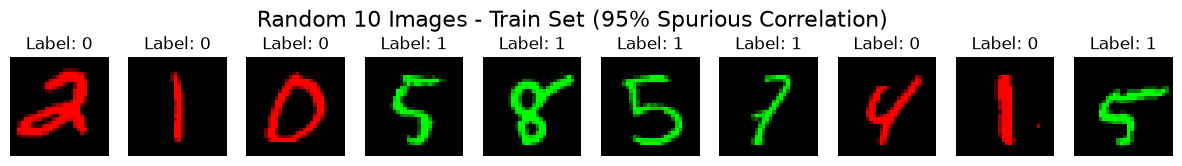

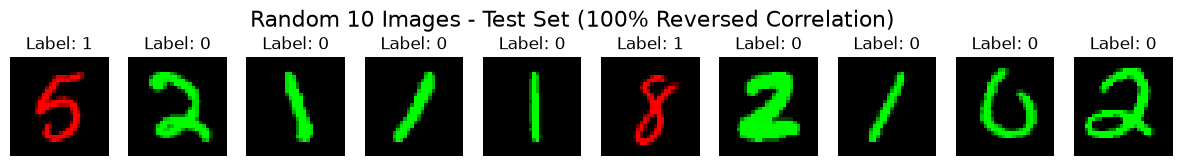

In [10]:
train_dataset = ColoredMNIST('../data/Q1/train-images-idx3-ubyte.gz', '../data/Q1/train-labels-idx1-ubyte.gz', train=True)
test_dataset = ColoredMNIST('../data/Q1/t10k-images-idx3-ubyte.gz', '../data/Q1/t10k-labels-idx1-ubyte.gz', train=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


plot_samples(train_dataset, 'Random 10 Images - Train Set (95% Spurious Correlation)')
plot_samples(test_dataset, 'Random 10 Images - Test Set (100% Reversed Correlation)')


# Model Architecture

In [10]:
class SimpleMLP(nn.Module):
    def __init__(self, hidden_dim=128):
        super(SimpleMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 28 * 28, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x):
        return self.net(x)

# ERM

In [12]:
loss_train_hist = []
loss_valid_hist = []

acc_train_hist = []
acc_valid_hist = []

epoch_counter = 0

In [13]:
set_seed(seed)
model = SimpleMLP().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [14]:
num_epochs = 2

for epoch in range(num_epochs):
  model, loss_train, acc_train = train_one_epoch(model, train_loader, loss_fn, optimizer, epoch_counter + 1)

  loss_valid, acc_valid = validation(model, test_loader, loss_fn)
  
  loss_train_hist.append(loss_train)
  loss_valid_hist.append(loss_valid)

  acc_train_hist.append(acc_train)
  acc_valid_hist.append(acc_valid)

  print(f'Valid: Loss = {loss_valid:.4}, Acc = {acc_valid:.4}')
  print()

  epoch_counter += 1

Epoch 1: 100%|██████████| 469/469 [00:03<00:00, 140.94batch/s, accuracy=95.5, loss=0.138]


Valid: Loss = 1.235, Acc = 0.2553



Epoch 2: 100%|██████████| 469/469 [00:02<00:00, 182.60batch/s, accuracy=96.8, loss=0.083] 


Valid: Loss = 0.8558, Acc = 0.6787



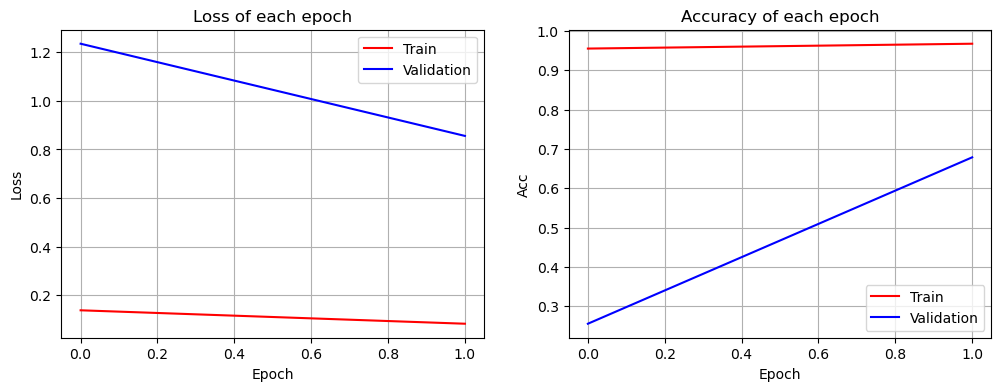

In [15]:
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.plot(range(epoch_counter), loss_train_hist, 'r-', label='Train')
plt.plot(range(epoch_counter), loss_valid_hist, 'b-', label='Validation')
plt.title('Loss of each epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(epoch_counter), acc_train_hist, 'r-', label='Train')
plt.plot(range(epoch_counter), acc_valid_hist, 'b-', label='Validation')
plt.title('Accuracy of each epoch')
plt.xlabel('Epoch')
plt.ylabel('Acc')
plt.grid(True)
plt.legend()

# Error Set

In [16]:
def get_error_indices(model, dataset):
    model.eval()
    error_indices = []
    
    eval_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    current_idx = 0
    with torch.no_grad():
        for inputs, targets in eval_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            
            batch_errors = (preds != targets).nonzero(as_tuple=True)[0]
            for idx in batch_errors:
                error_indices.append(current_idx + idx.item())
                
            current_idx += inputs.size(0)
            
    return error_indices

error_indices = get_error_indices(model, train_dataset)
print(f'Number of samples in Error Set: {len(error_indices)}')

Number of samples in Error Set: 1110


# Upsampling

In [17]:
U = 50

error_subset = Subset(train_dataset, error_indices)

# it exists once, so (U - 1)
upsampled_datasets = [train_dataset] + [error_subset] * (U - 1)

weighted_train_dataset = ConcatDataset(upsampled_datasets)
print(f'Original dataset size: {len(train_dataset)}')
print(f'Weighted dataset size: {len(weighted_train_dataset)}')

weighted_train_loader = DataLoader(weighted_train_dataset, batch_size=128, shuffle=True)


Original dataset size: 60000
Weighted dataset size: 114390


# JTT

In [18]:
loss_train_hist_jtt = []
loss_valid_hist_jtt = []

acc_train_hist_jtt = []
acc_valid_hist_jtt = []

epoch_counter_jtt = 0

In [19]:
set_seed(seed)
model_jtt = SimpleMLP().to(device)

optimizer_jtt = optim.Adam(model_jtt.parameters(), lr=0.001)
loss_fn_jtt = nn.CrossEntropyLoss()

In [20]:
num_epochs = 3

for epoch in range(num_epochs):
  model_jtt, loss_train, acc_train = train_one_epoch(model_jtt, weighted_train_loader, loss_fn_jtt, optimizer_jtt, epoch_counter_jtt + 1)

  loss_valid, acc_valid = validation(model_jtt, test_loader, loss_fn_jtt)
  
  loss_train_hist_jtt.append(loss_train)
  loss_valid_hist_jtt.append(loss_valid)

  acc_train_hist_jtt.append(acc_train)
  acc_valid_hist_jtt.append(acc_valid)

  print(f'Valid: Loss = {loss_valid:.4}, Acc = {acc_valid:.4}')
  print()

  epoch_counter_jtt += 1

Epoch 1: 100%|██████████| 894/894 [00:05<00:00, 167.88batch/s, accuracy=93.9, loss=0.16] 


Valid: Loss = 0.3823, Acc = 0.8696



Epoch 2: 100%|██████████| 894/894 [00:06<00:00, 139.53batch/s, accuracy=99.5, loss=0.021] 


Valid: Loss = 0.5977, Acc = 0.8358



Epoch 3: 100%|██████████| 894/894 [00:06<00:00, 131.99batch/s, accuracy=99.8, loss=0.00952]


Valid: Loss = 0.5948, Acc = 0.853



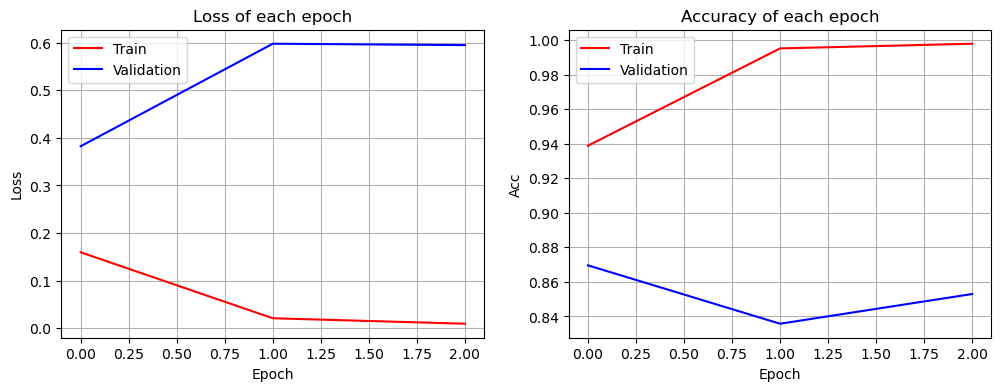

In [21]:
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.plot(range(epoch_counter_jtt), loss_train_hist_jtt, 'r-', label='Train')
plt.plot(range(epoch_counter_jtt), loss_valid_hist_jtt, 'b-', label='Validation')
plt.title('Loss of each epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(epoch_counter_jtt), acc_train_hist_jtt, 'r-', label='Train')
plt.plot(range(epoch_counter_jtt), acc_valid_hist_jtt, 'b-', label='Validation')
plt.title('Accuracy of each epoch')
plt.xlabel('Epoch')
plt.ylabel('Acc')
plt.grid(True)
plt.legend()

# GCE

In [11]:
class GCELoss(nn.Module):
    def __init__(self, q=0.7):
        super(GCELoss, self).__init__()
        self.q = q

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        true_probs = torch.gather(probs, 1, targets.unsqueeze(1)).squeeze(1)
        
        loss = (1 - torch.pow(true_probs + 1e-8, self.q)) / self.q
        return loss.mean()

In [23]:
loss_train_hist_gce = []
loss_valid_hist_gce = []

acc_train_hist_gce = []
acc_valid_hist_gce = []

epoch_counter_gce = 0

In [24]:
set_seed(seed)
model_gce = SimpleMLP().to(device)

optimizer_gce = optim.Adam(model_gce.parameters(), lr=0.001)
loss_fn_gce = GCELoss()

In [25]:
num_epochs = 2

for epoch in range(num_epochs):
  model_gce, loss_train, acc_train = train_one_epoch(model_gce, train_loader, loss_fn_gce, optimizer_gce, epoch_counter_gce + 1)

  loss_valid, acc_valid = validation(model_gce, test_loader, loss_fn_gce)
  
  loss_train_hist_gce.append(loss_train)
  loss_valid_hist_gce.append(loss_valid)

  acc_train_hist_gce.append(acc_train)
  acc_valid_hist_gce.append(acc_valid)

  print(f'Valid: Loss = {loss_valid:.4}, Acc = {acc_valid:.4}')
  print()

  epoch_counter_gce += 1

Epoch 1: 100%|██████████| 469/469 [00:03<00:00, 121.34batch/s, accuracy=95.1, loss=0.073] 


Valid: Loss = 1.33, Acc = 0.0739



Epoch 2: 100%|██████████| 469/469 [00:03<00:00, 132.79batch/s, accuracy=95.8, loss=0.0623]


Valid: Loss = 1.189, Acc = 0.1939



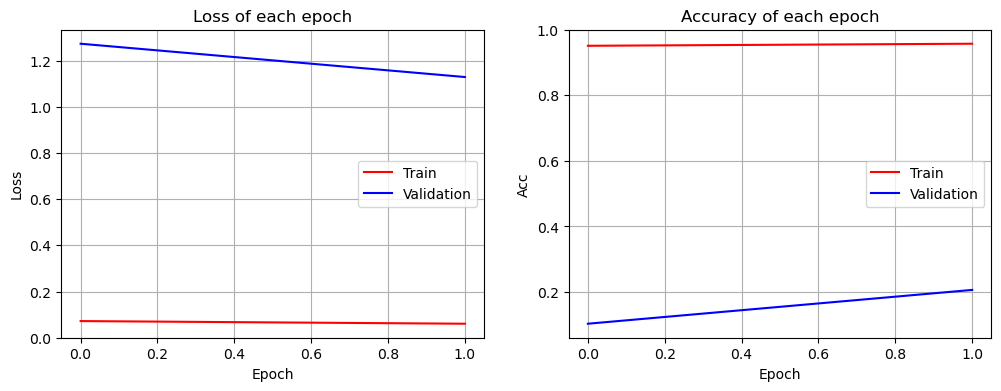

In [26]:
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.plot(range(epoch_counter_gce), loss_train_hist_gce, 'r-', label='Train')
plt.plot(range(epoch_counter_gce), loss_valid_hist_gce, 'b-', label='Validation')
plt.title('Loss of each epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(epoch_counter_gce), acc_train_hist_gce, 'r-', label='Train')
plt.plot(range(epoch_counter_gce), acc_valid_hist_gce, 'b-', label='Validation')
plt.title('Accuracy of each epoch')
plt.xlabel('Epoch')
plt.ylabel('Acc')
plt.grid(True)
plt.legend()

In [28]:
error_indices_gce = get_error_indices(model_gce, train_dataset)
print(f'Number of samples in Error Set (GCE): {len(error_indices_gce)}')

Number of samples in Error Set (GCE): 2366
